# 소비재 분야 기업들의 감사보수에 영향을 주는 요인 분석

소비재(식품·음료·생활용품·화장품) 분야 상장기업 12개사의 재무데이터와 감사보수 데이터를 읽어들여
데이터를 통합·분석 및 전처리한 후, 다양한 머신러닝 회귀 모델로 감사보수를 예측하고
어떤 요인이 감사보수에 영향을 주는지 분석합니다.

---
company: 기업명 / year: 회계연도 / industry: 업종 <br>
assets: 자산총계 / revenue: 매출액 / debt: 부채총계 / equity: 자본총계 <br>
auditor: 감사인(회계법인명) / audit_opinion: 감사의견 <br>
audit_fee: 감사보수(백만원) / audit_hours: 감사시간 <br>

---
> 데이터 출처: DART(전자공시시스템) Open API로 사전 수집한 데이터입니다.
> 실제 API로 데이터를 수집하고 싶다면 별도 제공된 `dart_audit_fee_collector.py`를 참고하세요.


## 0. 전 과정에서 사용할 기본 라이브러리 준비

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
plt.rc("font", family="NanumGothicCoding")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import random
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


## 1. 데이터 수집 및 통합

재무정보와 감사보수정보가 각각 다른 CSV 파일로 되어 있어, 두 데이터를 기업명(company)과
회계연도(year) 기준으로 병합하여 하나의 데이터프레임으로 통합합니다.

In [2]:
fin_df = pd.read_csv("소비재_재무정보.csv")
audit_df = pd.read_csv("소비재_감사보수정보.csv")

print(fin_df.shape, audit_df.shape)

df = pd.merge(fin_df, audit_df, on=["company", "year"], how="inner")
print(df.shape)
df.head()


(72, 7) (72, 6)
(72, 11)


,company,year,industry,assets,revenue,debt,equity,auditor,audit_opinion,audit_fee,audit_hours
0,CJ제일제당,2018,식품,2.893164e+12,3.387312e+12,1.098753e+12,1.794411e+12,정동회계법인,적정,199.6,805.0
1,CJ제일제당,2019,식품,2.982695e+12,3.725536e+12,1.347512e+12,1.635182e+12,정동회계법인,적정,185.2,1078.0
2,CJ제일제당,2020,식품,3.243499e+12,3.893230e+12,1.315450e+12,1.928049e+12,대주회계법인,적정,196.3,1119.0
3,CJ제일제당,2021,식품,3.057789e+12,3.865588e+12,1.129594e+12,1.928195e+12,대주회계법인,적정,192.5,849.0
4,CJ제일제당,2022,식품,3.148723e+12,3.528127e+12,1.369459e+12,1.779264e+12,성지회계법인,적정,194.6,1151.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 72 entries, 0 to 71
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   company        72 non-null     object 
 1   year           72 non-null     int64  
 2   industry       72 non-null     object 
 3   assets         72 non-null     float64
 4   revenue        72 non-null     float64
 5   debt           72 non-null     float64
 6   equity         72 non-null     float64
 7   auditor        72 non-null     object 
 8   audit_opinion  72 non-null     object 
 9   audit_fee      72 non-null     float64
 10  audit_hours    72 non-null     float64
dtypes: float64(6), int64(1), object(4)
memory usage: 6.8+ KB


## 2. 범주형 변수 EDA (분포 파악)

감사인(auditor), 업종(industry), 감사의견(audit_opinion)의 분포를 확인합니다.

findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\U

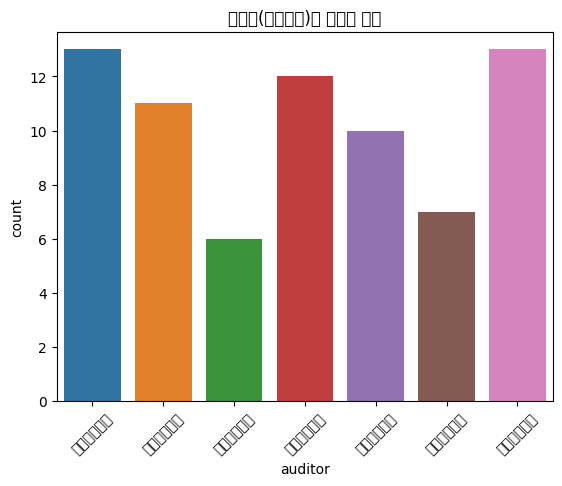

In [4]:
sns.countplot(data=df, x="auditor")
plt.xticks(rotation=45)
plt.title("감사인(회계법인)별 데이터 개수")
plt.show()


findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.

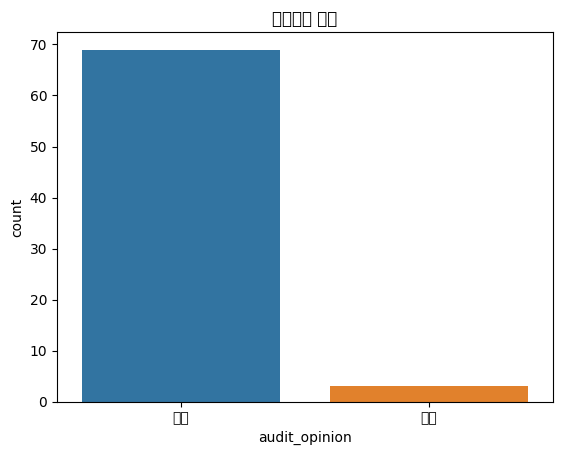

In [5]:
sns.countplot(data=df, x="audit_opinion")
plt.title("감사의견 분포")
plt.show()


findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users

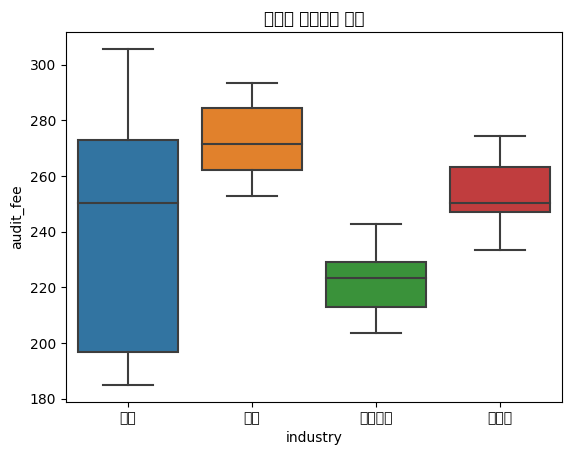

In [6]:
sns.boxplot(data=df, x="industry", y="audit_fee")
plt.title("업종별 감사보수 분포")
plt.show()


## 3. 범주형 변수 이진화 (피처 엔지니어링)

감사보수 결정요인 관련 선행연구에서 자주 다루는 두 가지 이진 변수를 생성합니다.
- `is_big4`: 감사인이 Big4(삼일·삼정·한영·안진회계법인) 여부
- `is_clean_opinion`: 감사의견이 '적정'인지 여부

In [7]:
big4_list = ["삼일회계법인", "삼정회계법인", "한영회계법인", "안진회계법인"]

df["is_big4"] = df["auditor"].isin(big4_list).astype(int)
df["is_clean_opinion"] = (df["audit_opinion"] == "적정").astype(int)

df[["auditor", "is_big4", "audit_opinion", "is_clean_opinion"]].drop_duplicates().head(10)


,auditor,is_big4,audit_opinion,is_clean_opinion
0,정동회계법인,0,적정,1
2,대주회계법인,0,적정,1
4,성지회계법인,0,적정,1
5,성지회계법인,0,한정,0
6,삼일회계법인,1,적정,1
7,안진회계법인,1,적정,1
8,삼정회계법인,1,적정,1
9,한영회계법인,1,적정,1
14,한영회계법인,1,한정,0
26,안진회계법인,1,한정,0


findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\cor

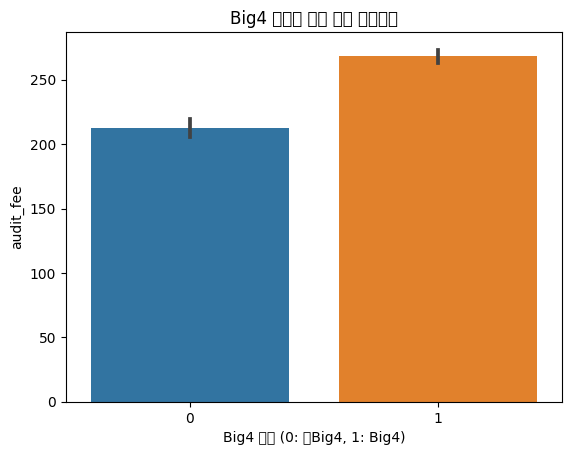

In [8]:
sns.barplot(data=df, x="is_big4", y="audit_fee")
plt.title("Big4 여부에 따른 평균 감사보수")
plt.xlabel("Big4 여부 (0: 비Big4, 1: Big4)")
plt.show()


## 4. 다른 변수들 간의 상관관계 분석

findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not 

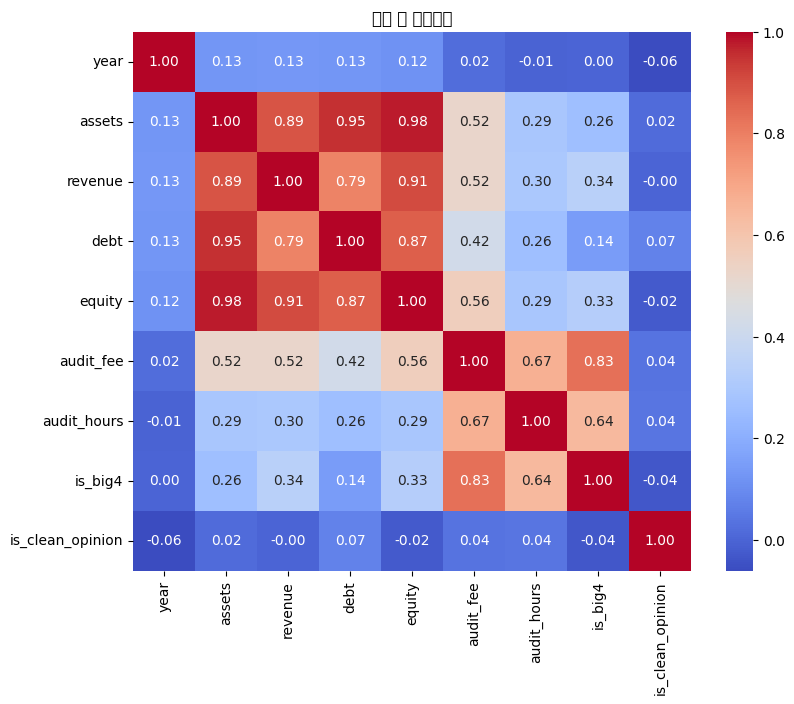

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("변수 간 상관관계")
plt.show()


## 5. 불필요 변수 제거

기업명(company)과 회계연도(year)는 식별자 성격의 변수이고, auditor·audit_opinion은
이미 이진 변수(is_big4, is_clean_opinion)로 피처 엔지니어링을 완료했으므로 원본 컬럼을 제거합니다.

In [10]:
df_reduced = df.drop(["company", "year", "auditor", "audit_opinion"], axis=1)
df_reduced.head()


,industry,assets,revenue,debt,equity,audit_fee,audit_hours,is_big4,is_clean_opinion
0,식품,2.893164e+12,3.387312e+12,1.098753e+12,1.794411e+12,199.6,805.0,0,1
1,식품,2.982695e+12,3.725536e+12,1.347512e+12,1.635182e+12,185.2,1078.0,0,1
2,식품,3.243499e+12,3.893230e+12,1.315450e+12,1.928049e+12,196.3,1119.0,0,1
3,식품,3.057789e+12,3.865588e+12,1.129594e+12,1.928195e+12,192.5,849.0,0,1
4,식품,3.148723e+12,3.528127e+12,1.369459e+12,1.779264e+12,194.6,1151.0,0,1


## 6. 결측치 처리

In [11]:
print(df_reduced.isnull().sum())

df_clean = df_reduced.dropna().reset_index(drop=True)
df_clean.shape


industry            0
assets              0
revenue             0
debt                0
equity              0
audit_fee           0
audit_hours         0
is_big4             0
is_clean_opinion    0
dtype: int64


(72, 9)

## 7. 범주형 변수의 수치화 (인코딩)

남아있는 범주형 변수는 업종(industry) 하나이며, get_dummies로 원-핫 인코딩합니다.

In [12]:
df_encoded = pd.get_dummies(df_clean, columns=["industry"])
df_encoded.head()


,assets,revenue,debt,equity,audit_fee,audit_hours,is_big4,is_clean_opinion,industry_생활용품,industry_식품,industry_음료,industry_화장품
0,2.893164e+12,3.387312e+12,1.098753e+12,1.794411e+12,199.6,805.0,0,1,0,1,0,0
1,2.982695e+12,3.725536e+12,1.347512e+12,1.635182e+12,185.2,1078.0,0,1,0,1,0,0
2,3.243499e+12,3.893230e+12,1.315450e+12,1.928049e+12,196.3,1119.0,0,1,0,1,0,0
3,3.057789e+12,3.865588e+12,1.129594e+12,1.928195e+12,192.5,849.0,0,1,0,1,0,0
4,3.148723e+12,3.528127e+12,1.369459e+12,1.779264e+12,194.6,1151.0,0,1,0,1,0,0


## 8. 데이터 분할 및 정규화

감사보수(audit_fee)를 예측 대상(y)으로, 나머지 변수를 피처(X)로 설정하여
훈련/검증 데이터셋을 8:2로 분할하고 StandardScaler로 정규화합니다.

In [13]:
X = df_encoded.drop("audit_fee", axis=1)
y = df_encoded["audit_fee"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print(X_train_scaled.shape, X_valid_scaled.shape)


(57, 11) (15, 11)


## 9. 다양한 머신러닝 회귀 모델 학습

선형회귀, 랜덤포레스트, 그래디언트부스팅, XGBoost 네 가지 회귀 모델을 학습합니다.

In [14]:
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgbr = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)

models = {"LinearRegression": lr, "RandomForest": rf, "GradientBoosting": gbr, "XGBoost": xgbr}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} 학습 완료")


LinearRegression 학습 완료
RandomForest 학습 완료
GradientBoosting 학습 완료
[14:55:13] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
XGBoost 학습 완료


## 10. 모델 성능 평가 및 최적 모델 선정

MAE, RMSE, R2 세 가지 지표로 네 개 모델의 성능을 비교하고 최적 모델을 선정합니다.

In [15]:
results = []

for name, model in models.items():
    pred = model.predict(X_valid_scaled)
    mae = mean_absolute_error(y_valid, pred)
    rmse = mean_squared_error(y_valid, pred) ** 0.5
    r2 = r2_score(y_valid, pred)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

result_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
result_df


,model,MAE,RMSE,R2
0,GradientBoosting,11.266438,13.928004,0.815798
1,RandomForest,11.324853,14.143168,0.810063
2,XGBoost,12.471321,15.898767,0.759982
3,LinearRegression,13.777299,15.912764,0.759560


findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HA

최적 모델: GradientBoosting


findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not 

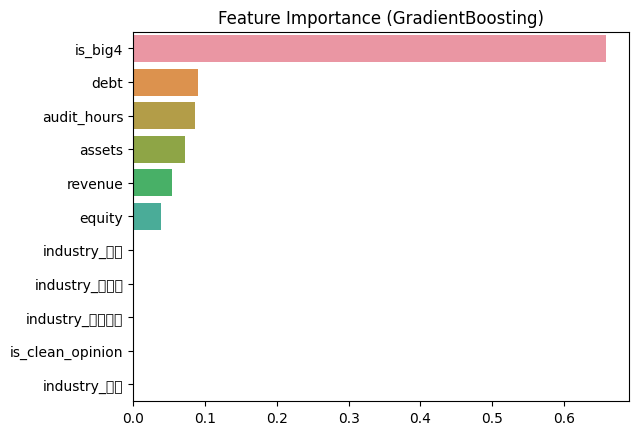

is_big4             0.657830
debt                0.090126
audit_hours         0.085536
assets              0.072534
revenue             0.053621
equity              0.039087
industry_식품         0.000941
industry_화장품        0.000128
industry_생활용품       0.000099
is_clean_opinion    0.000089
industry_음료         0.000009
dtype: float64


In [16]:
best_model_name = result_df.iloc[0]["model"]
best_model = models[best_model_name]
print("최적 모델:", best_model_name)

if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"Feature Importance ({best_model_name})")
    plt.show()
    print(importance)


## 11. 학습 곡선 시각화를 통한 모델 학습 상태 점검

딥러닝(Keras) 모델을 추가로 학습하여, epoch별 train loss와 validation loss 추이를 통해
모델이 과소적합/과대적합 없이 잘 학습되었는지 점검합니다.

In [17]:
model_dl = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1, activation="linear"),
])

model_dl.compile(optimizer="adam", loss="mse", metrics=["mae"])

es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
mc = ModelCheckpoint("best_audit_fee_model.h5", save_best_only=True)

history = model_dl.fit(
    X_train_scaled, y_train,
    epochs=100, batch_size=8,
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[es, mc],
    verbose=0,
)

print("학습 종료, 총 epoch:", len(history.history["loss"]))


C:\Users\USER\anaconda3\envs\aice\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


학습 종료, 총 epoch: 100


findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users

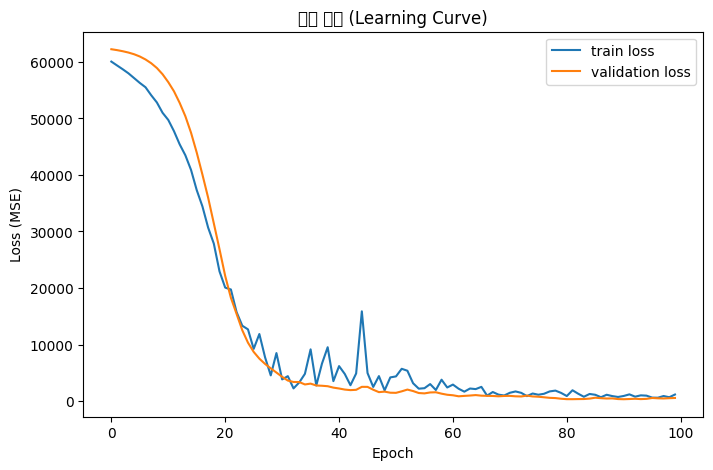

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("학습 곡선 (Learning Curve)")
plt.legend()
plt.show()


In [19]:
dl_pred = model_dl.predict(X_valid_scaled).flatten()
dl_mae = mean_absolute_error(y_valid, dl_pred)
dl_r2 = r2_score(y_valid, dl_pred)

print("딥러닝 모델 MAE:", dl_mae)
print("딥러닝 모델 R2:", dl_r2)


1/1 [==============================] - 0s 137ms/step
딥러닝 모델 MAE: 19.47654439290364
딥러닝 모델 R2: 0.469469822073455


### 분석 결론

- 상관관계 분석과 Feature Importance 결과를 통해, Big4 여부(is_big4)가
  감사보수에 큰 영향을 미치는 것으로 나타났습니다. 이는 감사보수 결정요인에 관한 기존 연구
  (감사인 유형)와 일치하는 결과입니다.
- 학습 곡선을 통해 딥러닝 모델이 특정 시점 이후 validation loss가 더 이상 개선되지 않아
  EarlyStopping으로 적절히 종료되었음을 확인했습니다.
- 다만 표본 수(12개사 x 6개년 = 72건)가 적어 일반화에는 한계가 있으며, 본 분석은 감사보수
  결정요인을 데이터 기반으로 탐색하는 접근법을 보여주기 위한 포트폴리오입니다.
